# Galactic Transparency Maps and Gamma-Ray Horizons

This tutorial demonstrates how to produge large-scale survival probability maps using the GPSP atlas.

The examples include:

- Bird's-eye Galactic transparency maps
- Gamma-ray horizon calculations
- Galactic plane survival probability maps
- Exporting Galactic plane survival probability map slices to FITS files

These examples provide an intuitive view of how the Milky Way becomes increasingly opaque to very-high-energy gamma rays.

---

**Important**

Some examples in this notebook are computationally intensive and may require high amount of memory ($\geq$ 16 GB).

For large map production, it is generally recommended to execute the provided Python scripts outside Jupyter notebooks. Ready-to-use scripts are available in the "Example Scripts" section of the documentation.

### Imports

**Import the required Python packages and GPSP helper modules. Be sure that the GPSPAtlasHelper and GPSPLIVAtlasHelper modules are in your system path.**

In [10]:
import os
import sys

# Do not forget to edit here!
sys.path.insert(0, os.path.abspath("../../../gpsp-atlas"))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
import matplotlib.cm as cm
from matplotlib.ticker import LogLocator, LogFormatterSciNotation, MultipleLocator
from matplotlib.lines import Line2D

from scipy.ndimage import gaussian_filter
from gpsp_atlas_helper import GPSPAtlasHelper
from gpsp_liv_atlas_helper import GPSPLIVAtlasHelper

**The following settings are used throughout this notebook to ensure consistent figure styling.**

In [15]:
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 8  # Changes the 90, 180, 270 labels

# Force X11/Xcb for stable rendering
os.environ["QT_QPA_PLATFORM"] = "xcb"

## Bird's-Eye Galactic Transparency Maps

Bird's-eye maps visualize the average survival probability of gamma rays throughout the Galactic disk.

For a given energy and latitude integration range (i.e. $b_{min}$ $<$ $b$ < $b_{max}$),

$
P_{\rm surv}(l,d)
$

is projected onto a polar representation of the Milky Way.

The Galactic Center is shown at the origin, while the Solar position is marked at a Galactocentric distance of approximately 8.5 kpc.

### Notes

- The maps shown here correspond to the standard Lorentz-invariant **GPSP R12** atlas. However, same maps can be produced for the LIV case using **GPSP-LIV** atlas and **GPSPLIVAtlasHelper** module.
- Spiral-arm tangent directions can be overlaid to highlight regions of enhanced attenuation.

In [4]:
# CONFIGURATION ---
FILE_PATH = "GPSP_Atlas_R12.fits"
ENERGIES_TEV = [100, 150, 200, 250]
# Define the min/max latitude interval
B_LOWER, B_UPPER = -1.0, 1.0
# Define colorbar (P_surv) min/max values
vmin = 0.7
vmax = 1.0
# Contour Settings: Levels, colors, linestyles. 
CONTOUR_LEVELS = [0.75, 0.80, 0.85]
CONTOUR_COLORS = ['white']
CONTOUR_LINESTYLES = ['dotted', 'dashed', 'solid']

# Tangential Arms [Galactic Longitude (l), Uncertainty of Longitude (dl)] --> i.e. 329 deg +/- 3 deg.
ARMS = {"Norma-3 kpc": [329, 3], "Scutum–Crux": [27, 3],}

### Generating Bird's-Eye Maps

The following example produces bird's view transparency maps at four representative enegies (ENERGIES_TEV = [100, 150, 200, 250]) and visualizes them in a polar Galactic projection next to each other.

For each energy:

1. A latitude-integrated transparency map is extracted from the atlas.
2. The map is smoothed for contour visualization.
3. Characteristic survival-probability contours are overlaid.

In [ ]:
# DATA EXTRACTION & PLOTTING ---
helper = GPSPAtlasHelper(FILE_PATH)
num_maps = len(ENERGIES_TEV)

fig, axes = plt.subplots(1, num_maps, subplot_kw={'projection': 'polar'}, figsize=(18, 5), constrained_layout=True)

for i, energy_tev in enumerate(ENERGIES_TEV):
    print("Processing Energy:", energy_tev)
    ax = axes[i]
    target_energy_ev = energy_tev * 1e12
    
    # Extraction
    # Note that we basically take all b values between B_LOWER and B_UPPER, and use the 50 percentile (median) value of the distribution.
    # Statistical methods to collapse the latitude axis, by default 'mean'.
    # Other methods are {'mean', 'median', 'min', 'max', 'percentile'}
    l_grid, d_axis, map_raw = helper.get_bird_view_map(target_energy_ev=target_energy_ev, b_lower=B_LOWER, b_upper=B_UPPER, 
                                                       method='percentile', percentile=50)

    L_mesh, D_mesh = np.meshgrid(np.radians(l_grid), d_axis, indexing='ij')
    map_smooth = gaussian_filter(map_raw, sigma=(12.0, 0.0), mode='wrap')

    # Polar Setup
    ax.set_facecolor('black')
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(1)
    ax.set_rasterization_zorder(1)

    # Base Map
    pc = ax.pcolormesh(L_mesh, D_mesh, map_raw, cmap='gist_heat', norm=LogNorm(vmin=vmin, vmax=vmax), 
                       shading='auto', zorder=0, edgecolor='face')

    # CONTOURS WITH BLACK SHADOWS ---
    # Solid black "trench" underneath for contrast
    ax.contour(L_mesh, D_mesh, map_smooth, levels=CONTOUR_LEVELS, colors='black', linewidths=2.2, zorder=0.4, linestyles='solid')

    # Main white contours
    cs = ax.contour(L_mesh, D_mesh, map_smooth, levels=CONTOUR_LEVELS, 
                    colors=CONTOUR_COLORS, linestyles=CONTOUR_LINESTYLES, 
                    linewidths=1.4, zorder=0.5)

    # Arm Tangents
    for name, (l_mean, l_rms) in ARMS.items():
        
        theta_mid = np.radians(l_mean)
        ax.vlines(theta_mid, 0, 20, color='black', linestyle='-', linewidth=1.8, alpha=0.7, zorder=4.9)
        ax.vlines(theta_mid, 0, 20, color='lime', linestyle='--', linewidth=1.2, alpha=0.7, zorder=5.0)

    # Grid & Labels Formatting
    ax.set_xticks(np.radians([0, 90, 180 ,270]))
    #ax.set_xticklabels(['$0^\circ$', '$90^\circ$', '$180^\circ$', '$270^\circ$'], color='none', fontsize=8, fontweight='bold')
                       
    labels = ['$0^\circ$', '', '$180^\circ$', '']
    if i == 0: # Far left map
        labels = ['$0^\circ$', '$90^\circ$', '$180^\circ$', ''] 
    if i == num_maps - 1: # Far right map
        labels = ['$0^\circ$', '', '$180^\circ$', '$270^\circ$']
        
    ax.set_xticklabels(labels, fontweight='bold', fontsize=11, color='none')
    
    ax.set_rlim(0, 20)
    ax.set_yticks([5, 10, 15, 20])
    ax.set_yticklabels([]) 
    ax.grid(True, color='black', linestyle='--', alpha=0.3)

    # Markers
    ax.scatter(0, 0, marker='*', s=80, color='lime', zorder=5, edgecolor='black', linewidths=0.5)
    ax.scatter(0, 8.5, marker='o', s=30, color='cyan', zorder=5, edgecolor='black', linewidths=0.5)
    ax.scatter(1.393, 7.4, marker='*', s=80, color='purple', zorder=5, edgecolor='black', linewidths=0.5)
    
    ax.set_title(f"{energy_tev} TeV", fontsize=15, pad=25, fontweight='bold')

# --- COLORBAR BOLDING ---
cbar = fig.colorbar(pc, ax=axes, location='right', pad=0.02, shrink=0.7, aspect=25)
cbar.set_label('Survival Probability ($P_{surv}$)', fontsize=14, fontweight='bold')

# 3. Optional: If you want exactly "0.7, 0.8..." and they aren't showing up
# because it's a log scale, manually set the ticks
cbar.set_ticks([0.7, 0.8, 0.9, 1.0])
cbar.ax.set_yticklabels(['0.7', '0.8', '0.9', '1.0'], fontweight='bold', fontsize=12)

plt.show()

helper.close()

![Transparency Map](example_plots/bird_view_low.png)

## Gamma-Ray Horizons

A gamma-ray horizon is defined as the distance at which the survival probability reaches a specified threshold.

In the GPSP atlas paper the conventional choice

$
P_{\rm surv}=e^{-1}\approx0.37
$

corresponds to an optical depth of unity.

The following example compares:

- Standard Lorentz-invariant propagation
- LIV-modified propagation

for a range of LIV scales.

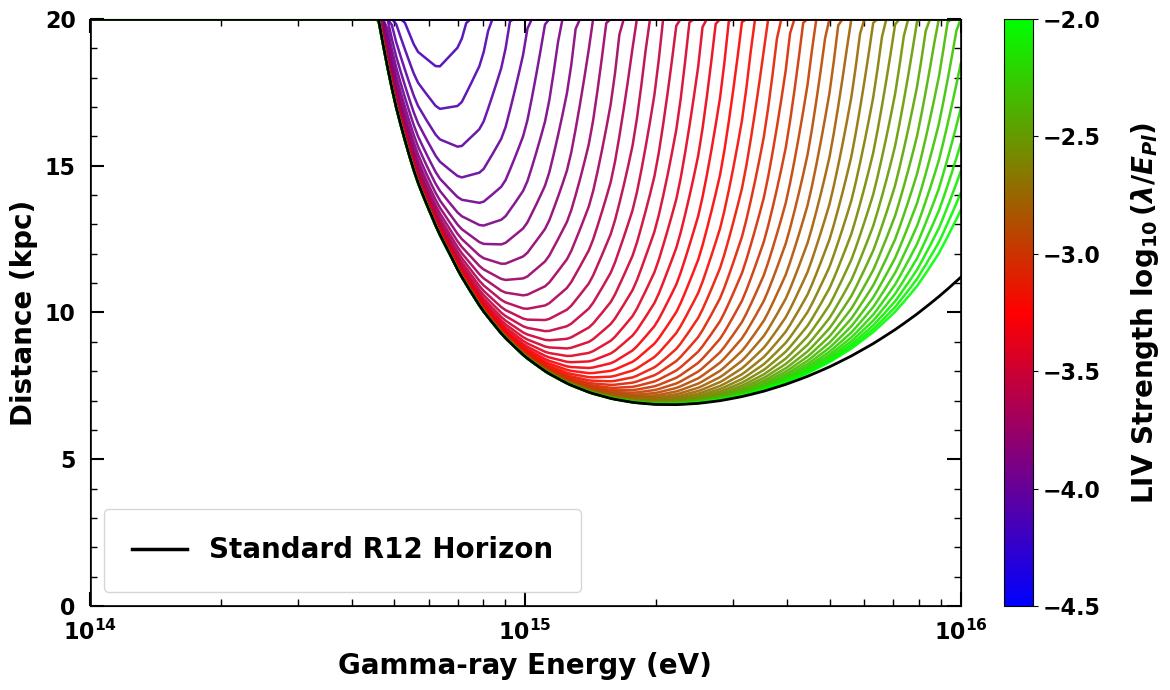

In [24]:
# Read atlas files
STD_ATLAS_FILE = "GPSP_Atlas_R12.fits"
LIV_ATLAS_FILE = "GPSP_Atlas_LIV_R12.fits"

helper_std = GPSPAtlasHelper(STD_ATLAS_FILE)
helper_liv = GPSPLIVAtlasHelper(LIV_ATLAS_FILE)

# Galactic Center (l,b) direction and P = 0.37 contour line.
TARGET_L = 0.0
TARGET_B = 0.0
LEVEL_HORIZON = 0.37

# Note that e_min is different for GPSP (1 TeV) and GPSP-LIV (100 TeV) atlases.
e_min = max(1e14, helper_liv.e_axis.min())
e_max = helper_liv.e_axis.max()
ENERGIES = np.logspace(np.log10(e_min), np.log10(e_max), 200)

# Lambda corresponds to LIV scale parameter.
lambda_values = helper_liv.lam_axis
norm = Normalize(vmin=min(lambda_values), vmax=max(lambda_values))
    
# Using Cividis for better visibility on white background
colormap = cm.brg 

fig, ax = plt.subplots(figsize=(12,7))

# Plot LIV Horizons
for lam in lambda_values:
    h_liv = helper_liv.get_horizon_distances(TARGET_L, TARGET_B, ENERGIES, lam, LEVEL_HORIZON)
    h_liv_fixed = np.where(np.isnan(h_liv), 20.0, h_liv)
    color = colormap(norm(lam))
    ax.plot(ENERGIES, h_liv_fixed, color=color, lw=1.8, alpha=0.9, zorder=5)

# Plot Reference Lines
h_std = helper_std.get_horizon_distances(TARGET_L, TARGET_B, ENERGIES, LEVEL_HORIZON)
ax.plot(ENERGIES, h_std, color='black', ls='-', lw=2.0, label='Standard GPSP R12 Horizon', zorder=10)
    
# Clamping boundaries to clean up the frame
ax.axhline(y=20.0, color='black', linestyle='-', linewidth=1.9, zorder=25)
ax.axhline(y=0.0, color='black', linestyle='-', linewidth=1.9, zorder=25)
ax.axvline(1e14, color='black', linestyle='-', linewidth=1.9, zorder=25)
ax.axvline(1e16, color='black', linestyle='-', linewidth=1.9, zorder=25)    

# Colorbar Styling
sm = cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.04) # Increased pad for distance from plot
cbar.set_label(r'LIV Strength $\log_{10}(\lambda/E_{Pl})$', fontsize=20, labelpad=20)
cbar.ax.tick_params(labelsize=16)

# AXES SPACING AND TICK FIXES
ax.set_xscale('log')
ax.set_xlim(1e14, 1e16) 
ax.set_ylim(0, 20) 
    
ax.set_xlabel('Gamma-ray Energy (eV)', labelpad=5, fontsize=20) # More space
ax.set_ylabel('Distance (kpc)', labelpad=5, fontsize=20)        # More space

# Control tick density
# Major ticks every decade (10^14, 10^15, 10^16)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=3)) 
# Minor ticks at 2,3,4,5,6,7,8,9 positions
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*.1, numticks=12))
ax.xaxis.set_major_formatter(LogFormatterSciNotation())
    
# Y-axis ticks: Major every 5 kpc, Minor every 1 kpc
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.set_minor_locator(MultipleLocator(1))

ax.tick_params(which='major', direction='in', top=True, right=True, length=10, width=1.5, pad=10, labelsize=16)
ax.tick_params(which='minor', direction='in', top=True, right=True, length=5, width=1.0, labelsize=16)
    
#ax.grid(True, which='major', alpha=0.3, ls=':')

# Custom Legend
custom_lines = [Line2D([0], [0], color='black', ls='-', lw=2.5, label='Standard R12 Horizon')]
ax.legend(handles=custom_lines, loc='lower left', frameon=True, borderpad=1, fontsize=20)

plt.tight_layout()
plt.show()

helper_std.close()
helper_liv.close()

### Physical Interpretation

LIV scenarios can substantially modify the transparency of the Galaxy at the highest energies.

Regions where the LIV horizon exceeds the standard horizon correspond to enhanced transparency caused by modifications of the pair-production threshold.

## Galactic Plane Transparency Maps

The GPSP helper module can also generate two-dimensional survival probability maps directly in Galactic coordinates (l,b). This basically corresponds to Galactic Plane survival probability maps.

For a fixed distance and energy,

$
P_{\rm surv}(l,b)
$

is evaluated across the sky and returned as a two-dimensional array.

---

### Memory Warning

Galactic plane maps are significantly more memory intensive than profile calculations.

For large atlas files:

- Jupyter notebooks may become unstable.
- Systems with $\leq$16 GB RAM may experience kernel crashes.
- Generating many maps sequentially inside notebooks is not recommended.

For production of such maps, it is strongly recommended to use standalone Python scripts provided in the "Example Scripts" section. 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from scipy.ndimage import gaussian_filter
from astropy.coordinates import SkyCoord
import astropy.units as u

from gpsp_atlas_helper import GPSPAtlasHelper

def shift_to_centered_coordinates(l_grid, map_2d):

    idx_180 = np.searchsorted(l_grid, 180.0)
    l_shifted = np.concatenate([l_grid[idx_180:] - 360, l_grid[:idx_180]])
    map_shifted = np.concatenate([map_2d[:, idx_180:], map_2d[:, :idx_180]], axis=1)

    return l_shifted, map_shifted
    
# Load GPSP map directly from helper
helper = GPSPAtlasHelper("GPSP_Atlas_R12.fits")

# Define energy and distance slice that will be extracted from the atlas.
energy_tev = 150
distance_kpc = 10.0

map_2d, l_grid, b_grid = helper.get_galactic_plane_map(target_energy_ev=energy_tev * 1e12, target_distance_kpc=distance_kpc,
                                                       b_lower=-5, b_upper=5)

helper.close()

# Plot settings
CONTOUR_LEVELS = [0.85, 0.90, 0.95]
CONTOUR_COLORS = ['yellow', 'cyan', 'magenta']
CONTOUR_LINESTYLES = 'dashed'

# This is for smoothing probability contours.
CONTOUR_SMOOTH_SIGMA = (1.0, 12.0)

# Define min/max of the colorbar
VMIN = 0.80
VMAX = 1.00

# Coordinate limits
B_MIN = b_grid[0]
B_MAX = b_grid[-1]

# Smoothing
map_smooth = gaussian_filter(map_2d, sigma=CONTOUR_SMOOTH_SIGMA, mode='wrap')
l_shifted, map_shifted = shift_to_centered_coordinates(l_grid, map_2d)
_, map_smooth_shifted = shift_to_centered_coordinates(l_grid, map_smooth)
L_mesh, B_mesh = np.meshgrid(l_shifted, b_grid)

# Plot
fig, ax = plt.subplots(figsize=(18, 3))
im = ax.pcolormesh(L_mesh, B_mesh, map_shifted, cmap='gist_heat', shading='auto', norm=Normalize(vmin=VMIN, vmax=VMAX))
ax.contour(L_mesh, B_mesh, map_smooth_shifted, levels=CONTOUR_LEVELS, colors='black', linewidths=2.8)
ax.contour(L_mesh, B_mesh, map_smooth_shifted, levels=CONTOUR_LEVELS, colors=CONTOUR_COLORS, linestyles=CONTOUR_LINESTYLES, linewidths=1.2)

# Example source marker
cygx3 = SkyCoord(ra=308.10*u.deg, dec=40.92*u.deg, frame='icrs')

l_cyg = cygx3.galactic.l.degree
b_cyg = cygx3.galactic.b.degree

if l_cyg > 180:
    l_cyg -= 360

ax.scatter(l_cyg, b_cyg, marker='*', s=120, color='lime', edgecolor='black', zorder=10)

# Formatting
ax.set_xlim(180, -180)
ax.set_ylim(B_MIN, B_MAX)
ax.set_xlabel("Galactic Longitude l (deg)")
ax.set_ylabel("Galactic Latitude b (deg)")
ax.text(175, B_MAX - 1.5, f"{energy_tev} TeV", color='white', fontsize=14, fontweight='bold', bbox=dict(facecolor='black', alpha=0.5))
ax.grid(linestyle='--', alpha=0.3)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Survival Probability")

plt.tight_layout()
plt.show()

![Galactic Plane Map](example_plots/gp_map_150TeV_10kpc.png)

## Exporting Transparency Maps to FITS

For the production of several maps, it is often advantageous to save extracted Galactic plane slices as standalone FITS files, and then plot them using another code.

Advantages:

- Faster plotting
- Lower memory consumption
- Easy sharing with collaborators
- Compatibility with standard astronomy software

The helper module can write the extracted slice directly to a FITS file.

In [ ]:
helper = GPSPAtlasHelper("GPSP_Atlas_R12.fits")

target_energy_ev = 250e12
target_distance_kpc = 10.0

# Using output_fits="GPSP_2D_Map_10kpc_250TeV.fits" argument produces a fits file for a given slice.
map_2d, l_grid, b_grid = helper.get_galactic_plane_map(target_energy_ev=target_energy_ev, target_distance_kpc=target_distance_kpc, 
                                                       b_lower=-5, b_upper=5,
                                                       output_fits="GPSP_2D_Map_10kpc_250TeV.fits")
                                                       
helper.close()                                                       

### Reading and Visualizing a Saved FITS Slice

Once a transparency map has been exported, it can be visualized independently of the original atlas.

This approach is recommended whenever multiple figures are generated.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u
from scipy.ndimage import gaussian_filter

# Force X11/Xcb for stable rendering
os.environ["QT_QPA_PLATFORM"] = "xcb"

def shift_to_centered_coordinates(l_grid, map_2d):
    idx_180 = np.searchsorted(l_grid, 180.0)
    l_shifted = np.concatenate([l_grid[idx_180:] - 360, l_grid[:idx_180]])
    map_shifted = np.concatenate([map_2d[:, idx_180:], map_2d[:, :idx_180]], axis=1)
    return l_shifted, map_shifted

if __name__ == "__main__":

    # Input FITS file corresponding to d=10 kpc and E=250 TeV slice.
    INPUT_2D_FITS = "GPSP_2D_Map_10kpc_250TeV.fits"

    energy = target_energy_ev/1e12
    
    CMAP_SCALING_MODE = 'absolute' 
    VMIN_ABSOLUTE = 0.80
    VMAX_ABSOLUTE = 1.00
    
    # CONTOUR SETTINGS
    CONTOUR_LEVELS = [0.85, 0.90, 0.95]
    CONTOUR_COLORS = ['yellow', 'cyan', 'magenta'] 
    CONTOUR_LINESTYLES = 'dashed' 
    CONTOUR_SMOOTH_SIGMA = (1.0, 12.0) 
    
    # CONTOUR SHADE (HALO) SETTINGS
    CONTOUR_SHADE_COLOR = 'black'  
    CONTOUR_SHADE_WIDTH = 2.8      

    # Some Galactic sources to plot on the map.
    custom_objects = [
        {'name': 'Galactic Center', 'frame': 'galactic', 'l': 0.0, 'b': 0.0, 
         'marker': '*', 'color': 'white', 'size': 120},
        {'name': 'Cygnus X-3', 'frame': 'icrs', 'ra': 308.10, 'dec': 40.92, 
         'marker': '*', 'color': 'lime', 'size': 120}
    ]

    plt.rcParams['font.weight'] = 'bold'
    plt.rcParams['axes.labelweight'] = 'bold'
    plt.rcParams['axes.titleweight'] = 'bold'

    # Load the 2D Data and Coordinates
    print(f"Loading {INPUT_2D_FITS}...")
    with fits.open(INPUT_2D_FITS) as hdul:
        map_2d = hdul[0].data
        hdr = hdul[0].header
        
        # Reconstruct grids using the saved header info
        n_l, n_b = hdr['NAXIS1'], hdr['NAXIS2']
        l_grid = hdr['CRVAL1'] + np.arange(n_l) * hdr['CDELT1']
        b_grid = hdr['CRVAL2'] + np.arange(n_b) * hdr['CDELT2']
        
        energy_tev = hdr.get('ENERGY', 'Unknown')
    
    B_MIN, B_MAX = b_grid[0], b_grid[-1]

    # Setup Figure
    fig, ax = plt.subplots(figsize=(18, 3))
    
    # Smoothing and Shifting
    map_smooth = gaussian_filter(map_2d, sigma=CONTOUR_SMOOTH_SIGMA, mode='wrap')
    l_shifted, map_shifted = shift_to_centered_coordinates(l_grid, map_2d)
    _, map_smooth_shifted = shift_to_centered_coordinates(l_grid, map_smooth)
    L_mesh, B_mesh = np.meshgrid(l_shifted, b_grid)
    
    # Scaling logic
    if CMAP_SCALING_MODE == 'absolute':
        vmn, vmx = VMIN_ABSOLUTE, VMAX_ABSOLUTE
    elif CMAP_SCALING_MODE == 'percentile':
        vmn, vmx = np.nanpercentile(map_shifted, 5), np.nanpercentile(map_shifted, 95)
    else:
        vmn, vmx = np.nanmin(map_shifted), np.nanmax(map_shifted)

    # Plotting Layers
    im = ax.pcolormesh(L_mesh, B_mesh, map_shifted, cmap='gist_heat', shading='auto',
                       norm=Normalize(vmin=vmn, vmax=vmx), rasterized=True)
    
    # Contour Shades
    ax.contour(L_mesh, B_mesh, map_smooth_shifted, levels=CONTOUR_LEVELS, 
               colors=CONTOUR_SHADE_COLOR, linestyles='solid', linewidths=CONTOUR_SHADE_WIDTH, alpha=0.9)
    
    # Main Contours
    ax.contour(L_mesh, B_mesh, map_smooth_shifted, levels=CONTOUR_LEVELS, 
               colors=CONTOUR_COLORS, linestyles=CONTOUR_LINESTYLES, linewidths=1.2)

    # Labels
    ax.set_ylabel('b (deg)', fontsize=12)
    ax.text(175, B_MAX - 1.5, f"{float(energy):.0f} TeV", color='white', fontweight='bold', 
            fontsize=14, bbox=dict(facecolor='black', alpha=0.5))
    
    # Custom Objects
    for obj in custom_objects:
        if obj['frame'] == 'icrs':
            coord = SkyCoord(ra=obj['ra']*u.deg, dec=obj['dec']*u.deg, frame='icrs')
            lo, bo = coord.galactic.l.degree, coord.galactic.b.degree
        else: lo, bo = obj['l'], obj['b']
        
        if lo > 180: lo -= 360
        if B_MIN <= bo <= B_MAX:
            ax.scatter(lo, bo, color=obj['color'], marker=obj['marker'], s=obj['size'], 
                       edgecolor='black', zorder=10)

    # Formatting axes limits and ticks
    ax.set_xlim(180, -180)
    ax.set_ylim(B_MIN, B_MAX)
    ax.grid(color='gray', linestyle='--', alpha=0.3)
    
    xticks = np.arange(180, -181, -30)
    ax.set_xticks(xticks)
    ax.set_xticklabels([f"{x if x >= 0 else x + 360}°" for x in xticks], fontsize=10)
    ax.set_xlabel('Galactic Longitude l (deg)', fontsize=12)

    # Align Colorbar
    plt.subplots_adjust(right=0.88)
    pos = ax.get_position()
    cbar_ax = fig.add_axes([0.89, pos.y0, 0.02, pos.y1 - pos.y0])
    
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label('Survival Probability', fontsize=12, fontweight='bold')
    cbar.ax.tick_params(labelsize=10)

    plt.show()

![FITS Slice Example](example_plots/Galactic_Plane_250TeV_10kpc.png)

## Summary

This tutorial demonstrated:

- Bird's-eye Galactic transparency maps
- Gamma-ray horizon calculations
- LIV versus standard horizon comparisons
- Galactic plane survival probability maps
- FITS export and visualization workflows

For large-scale map production, the recommended workflow is:

1. Generate maps using standalone Python scripts.
2. Export intermediate products as FITS files.
3. Perform visualization from the saved FITS slices.

This approach minimizes memory consumption and significantly accelerates repeated analyses.